# 03 · Model Probabilistik (Quantile Neural Network)

Model memprediksi **7 kuantil sekaligus** (5%, 10%, 25%, 50%, 75%, 90%, 95%) untuk 14 hari ke depan.

- **Loss: pinball loss.** Untuk kuantil τ, kesalahan *di bawah* prediksi diberi bobot τ dan di atas
  diberi bobot (1−τ). Akibatnya model "terdorong" ke kuantil yang benar.
- **Kuantil tidak saling silang.** Model memprediksi median, lalu menambah/mengurangi jarak positif
  (softplus), sehingga q05 ≤ q10 ≤ … ≤ q95 selalu terjamin.
- **Arsitektur:** MLP kecil (2 hidden layer × 128). Inputnya 56 hari histori + fitur kalender.

Di notebook ini model dilatih untuk **satu bank saja** (Local-only), sebagai fondasi sebelum federated.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
import torch
from fedprob.data import get_scenario, simulate, build_all_clients
from fedprob.experiment import _oracle_preds
from fedprob.models import QuantileMLP, ets_quantiles
from fedprob.training import TrainConfig, train_with_early_stopping, predict
from fedprob.metrics import evaluate, reliability
from fedprob.plots import plot_fan, plot_history, plot_reliability

sim = simulate(get_scenario("normal"))
clients = build_all_clients(sim)
c = clients[0]
model = QuantileMLP()
print(model)
print("jumlah parameter:", sum(p.numel() for p in model.parameters()))

QuantileMLP(
  (net): Sequential(
    (0): Linear(in_features=210, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=98, bias=True)
  )
)
jumlah parameter: 56162


epoch terbaik: 19


<Axes: title={'center': 'Pinball loss'}, xlabel='ronde / epoch', ylabel='val_loss'>

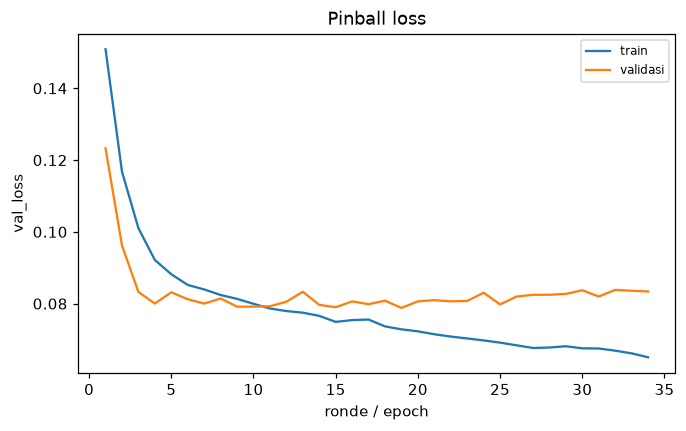

In [3]:
res = train_with_early_stopping([c], TrainConfig(epochs=80, patience=15))
print("epoch terbaik:", res.best_epoch)
plot_history({"train": [{"epoch": h["epoch"], "val_loss": h["train_loss"]} for h in res.history],
              "validasi": res.history}, title="Pinball loss")

In [4]:
p_nn = predict(res.model, c.test)
p_ets = ets_quantiles(sim, c)
p_or = _oracle_preds(sim, c)
pd.DataFrame({"QuantileMLP": evaluate(c.test.y, p_nn), "ETS": evaluate(c.test.y, p_ets),
              "Oracle": evaluate(c.test.y, p_or)}).T

,MAE,CRPS,Coverage50,Coverage80,Coverage90,Lebar80
QuantileMLP,0.359,0.217,0.353,0.589,0.706,0.788
ETS,0.331,0.189,0.537,0.829,0.935,1.183
Oracle,0.331,0.189,0.361,0.646,0.779,0.794


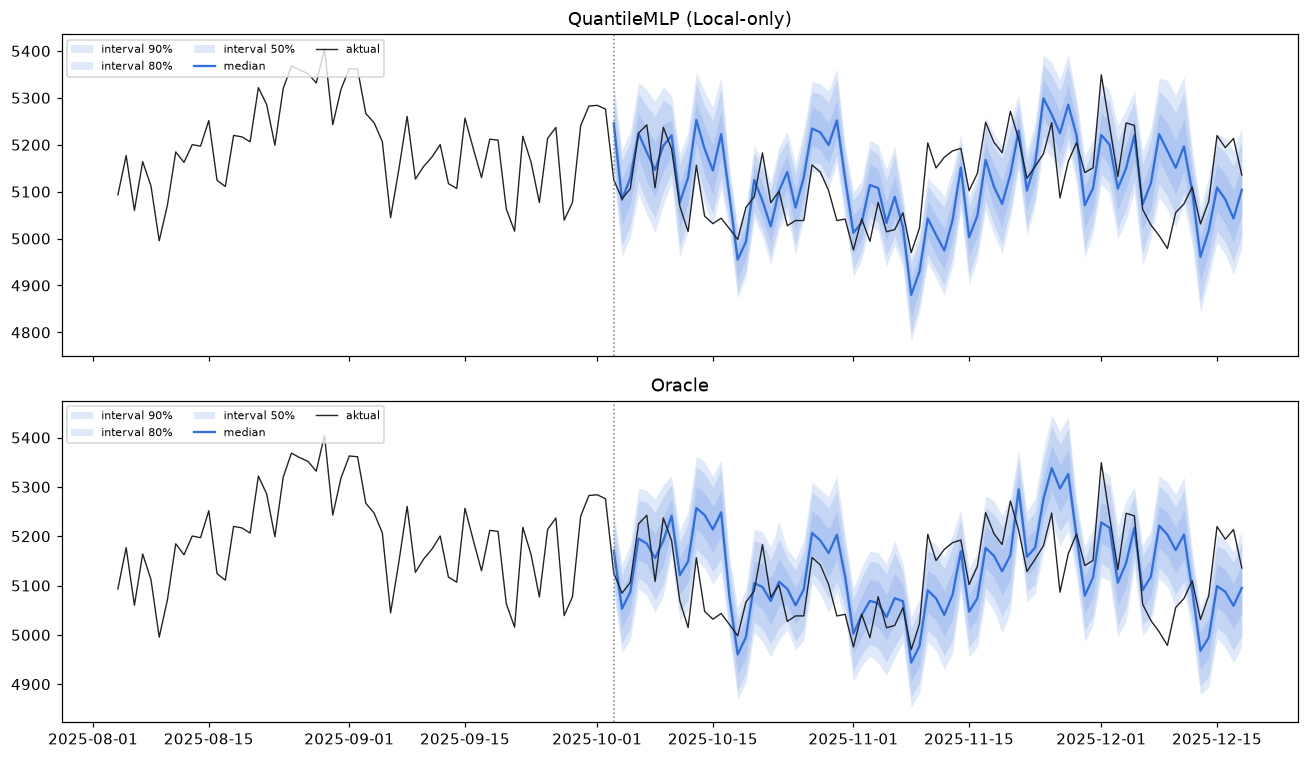

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_fan(sim, 0, c.denorm(p_nn), c.test.origins, ax=axes[0], title="QuantileMLP (Local-only)")
plot_fan(sim, 0, c.denorm(p_or), c.test.origins, ax=axes[1], title="Oracle")
plt.tight_layout()

## Bagaimana jika data sebuah bank sedikit?
Bank kecil dalam skenario `data_langka` hanya punya ~4 bulan histori. Model lokal sulit belajar dari
data sesedikit itu. **Inilah motivasi utama federated learning.**

In [6]:
sim_l = simulate(get_scenario("data_langka"))
cl = build_all_clients(sim_l)
rows = []
for k in [0, 5]:
    r = train_with_early_stopping([cl[k]], TrainConfig())
    rows.append({"bank": cl[k].name, "n_train": len(cl[k].train), **evaluate(cl[k].test.y, predict(r.model, cl[k].test))})
pd.DataFrame(rows)

,bank,n_train,MAE,CRPS,Coverage50,Coverage80,Coverage90,Lebar80
0,Bank A,847,0.359,0.217,0.353,0.589,0.706,0.788
1,Bank F,51,0.323,0.238,0.776,0.968,0.993,2.049
